1. Здійсніть імпорт необхідних бібліотек.

In [266]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score

from dataclasses import dataclass, field

from tqdm import tqdm

2. Підготовка даних:
 - Завантажте набір даних Intel Image Classification з платформи Kaggle.
- Розділіть дані на тренувальний, валідаційний та тестовий набори. Дані вже розділені на навчальні та тестові. Вам слід відділити частину навчальних даних для отримання валідаційного набору даних.
 - Використайте torchvision.datasets і torch.utils.data.DataLoader для завантаження та підготовки даних.
 - Застосуйте необхідні перетворення (наприклад, зміна розміру, нормалізація) за допомогою torchvision.transforms.

In [267]:
train_dir = '../data/hw_6_intel_image/seg_train'
test_dir  = '../data/hw_6_intel_image/seg_test'
pred_dir  = '../data/hw_6_intel_image/seg_pred'


In [268]:
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(15),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [269]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)
pred_dataset = datasets.ImageFolder(pred_dir, transform=val_transform)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


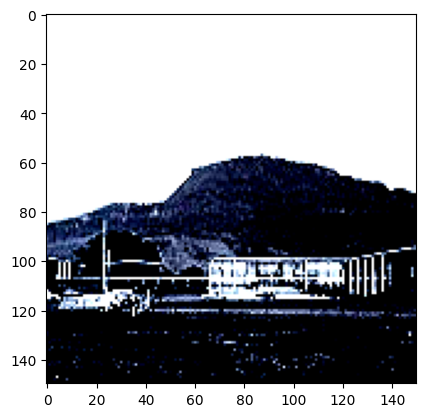

In [270]:
plt.imshow(train_dataset[0][0].permute(1, 2, 0))

In [271]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
pred_loader = DataLoader(pred_dataset , batch_size=32)

In [272]:
print(f"Кількість класів: {len(train_dataset.classes)}")
print(f"Класи: {train_dataset.classes}")
print(f"Розмір тренувального набору: {len(train_dataset)}")
print(f"Розмір валідаційного набору: {len(pred_dataset)}")
print(f"Розмір тестового набору: {len(test_dataset)}")

# Перевірка балансу класів у тренувальному наборі
class_counts = {class_name: 0 for class_name in train_dataset.classes}
for _, label in train_dataset.samples:
    class_counts[train_dataset.classes[label]] += 1

print("\nРозподіл класів у тренувальному наборі:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Кількість класів: 6
Класи: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Розмір тренувального набору: 14034
Розмір валідаційного набору: 1976
Розмір тестового набору: 3000

Розподіл класів у тренувальному наборі:
buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382


3. Створення моделі: Варіант A: Проста згорткова нейронна мережа

 - Створіть власну архітектуру CNN за допомогою torch.nn.
 - Визначте шари згортки (Conv2d), активації (ReLU), пулінгу (MaxPool2d) та повнозв'язні шари (Linear).

In [305]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()
        self.num_channels = 32
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Обчислити розмір вхідних даних для повнозв'язного шару
        self._initialize_fc_layer()
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(self.fc1_in_features, 512)
        self.fc2 = nn.Linear(512, num_classes)
    
    def _initialize_fc_layer(self):
        # Прокинемо зображення через конволюційні шари, щоб дізнатися розмір
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 150, 150)
            dummy_output = self._forward_conv_layers(dummy_input)
            self.fc1_in_features = dummy_output.numel()

    def _forward_conv_layers(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        return x

    def forward(self, x):
        x = self._forward_conv_layers(x)
        x = x.view(-1, self.fc1_in_features)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [306]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, **kwargs)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x))

class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):
        """
        in_channels: кількість каналів на вході в модуль
        out_1x1: вихідні канали для нижньої гілки (1x1)
        red_3x3, out_3x3: канали для гілки з 3x3 (red - це зменшення 1x1 перед 3x3)
        red_5x5, out_5x5: канали для гілки з 5x5
        out_pool: канали після пулінгу
        """
        super(InceptionModule, self).__init__()

        # Гілка 1 (верхня на малюнку): Conv 1x1 -> Conv 5x5
        self.branch1 = nn.Sequential(
            BasicConv2d(in_channels, red_5x5, kernel_size=1),
            BasicConv2d(red_5x5, out_5x5, kernel_size=5, padding=2) 
        )

        # Гілка 2 (друга зверху): Conv 1x1 -> Conv 3x3
        self.branch2 = nn.Sequential(
            BasicConv2d(in_channels, red_3x3, kernel_size=1),
            BasicConv2d(red_3x3, out_3x3, kernel_size=3, padding=1)
        )

        # Гілка 3 (третя зверху): MaxPool 3x3 -> Conv 1x1
        self.branch3 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, out_pool, kernel_size=1)
        )

        # Гілка 4 (нижня на малюнку): Conv 1x1
        self.branch4 = BasicConv2d(in_channels, out_1x1, kernel_size=1)

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        outputs = torch.cat([b1, b2, b3, b4], dim=1)
        
        return outputs
    
class InceptionCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(InceptionCNN, self).__init__()
        
        self.conv1 = BasicConv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.inception = InceptionModule(
            in_channels=32, 
            out_1x1=16,          
            red_3x3=16, out_3x3=32,  
            red_5x5=8,  out_5x5=16,  
            out_pool=16          
        )
        
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self._initialize_fc_layer()
        
        self.fc1 = nn.Linear(self.fc1_in_features, 512)

        #self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, num_classes)
    
    def _forward_features(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.inception(x))
        return x
        
    def _initialize_fc_layer(self):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 150, 150)
            dummy_output = self._forward_features(dummy_input)
            self.fc1_in_features = dummy_output.numel()

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(-1, self.fc1_in_features) 
        x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        x = self.fc2(x)
        return x

4. Варіант B: Transfer Learning

 - Імпортуйте попередньо навчену модель (наприклад, ResNet18) з torchvision.models.
 - Модифікуйте останній шар відповідно до кількості класів у вашому завданні.

In [275]:
class ResNet50Ex(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Ex, self).__init__()
        # Завантаження моделі ResNet50 з попередньо натренованими вагами
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Заморожування параметрів моделі (щоб не оновлювалися під час навчання)
        for param in self.model.parameters():
            param.requires_grad = False

        # Заміна останнього повнозв'язного шару (fc) на новий, відповідно до кількості класів
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes) 

    def forward(self, x):
        return self.model(x)

5. Визначення функції втрат та оптимізатора:

 - Виберіть відповідну функцію втрат (наприклад, CrossEntropyLoss). Обґрунтуйте вибір функції втрат.
 - Виберіть оптимізатор (наприклад, Adam або SGD).

In [276]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

@dataclass
class EvalResult:
    all_preds: list = field(default_factory=list)
    all_labels: list = field(default_factory=list)
    correct: int = 0
    total: int = 0


class ClassificationModel:
    def __init__(self, model, epoch:int, path: str):
        self.model = model

        self.criterion =  nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=0.001)

        self.num_epochs = epoch
        self.best_val_loss = float('inf')
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []
        self.storage_path = path

        self.result = EvalResult()

    def connect_to_device(self, device):
        self.model.to(device)
    
    def train_and_valid(self):
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in tqdm(train_loader):
                inputs, labels = inputs.to(device), labels.to(device)

                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            train_loss = running_loss / len(train_loader)
            train_accuracy = correct / total
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_accuracy)

            # Валідація
            self.model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in pred_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            val_loss /= len(pred_loader)
            val_accuracy = correct / total
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_accuracy)

            print(f'Epoch {epoch+1}/{self.num_epochs}:')
            print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
            print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                torch.save(self.model.state_dict(), self.storage_path)


    def evaluate_model(self):
        self.model.load_state_dict(torch.load(self.storage_path))
        self.model.eval()

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                self.result.total += labels.size(0)
                self.result.correct += (predicted == labels).sum().item()
                self.result.all_preds.extend(predicted.cpu().numpy())
                self.result.all_labels.extend(labels.cpu().numpy())


    def show_f1_score(self):
        # Обчислення точності та F1 
        test_accuracy = self.result.correct / self.result.total
        f1 = f1_score(self.result.all_labels, self.result.all_preds, average='weighted')

        print(f'Test Accuracy: {test_accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}')


    def show_confusion_matrix(self, class_names):
        # Створення матриці помилок
        cm = confusion_matrix(self.result.all_labels, self.result.all_preds)
        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()


    def plot_training_metrics(self):
        epochs = range(1, len(self.train_losses) + 1)

        plt.figure(figsize=(12, 5))

        # Plot loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, 'b-', label='Training Loss')
        plt.plot(epochs, self.val_losses, 'r-', label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        # Plot accuracy
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.train_accuracies, 'b-', label='Training Accuracy')
        plt.plot(epochs, self.val_accuracies, 'r-', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def visualize_predictions(self, dataloader, class_names, num_images=5):
        was_training = self.model.training
        self.model.eval()
        images_so_far = 0

        fig = plt.figure(figsize=(15, 10))

        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)

                for j in range(inputs.size(0)):
                    if images_so_far == num_images:
                        self.model.train(mode=was_training)
                        plt.tight_layout()
                        plt.show()
                        return

                    images_so_far += 1
                    ax = plt.subplot(num_images//2 + 1, 2, images_so_far)
                    ax.axis('off')
                    ax.set_title(f'Predicted: {class_names[preds[j]]}\nTrue: {class_names[labels[j]]}')

                    # Денормалізація зображення для відображення
                    inv_normalize = transforms.Normalize(
                        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                        std=[1/0.229, 1/0.224, 1/0.225]
                    )
                    inp = inv_normalize(inputs.cpu()[j]).numpy().transpose((1, 2, 0))
                    inp = np.clip(inp, 0, 1)

                    plt.imshow(inp)

        self.model.train(mode=was_training)
        plt.tight_layout()
        plt.show()
    

In [307]:
simplecnn_model = ClassificationModel(SimpleCNN(num_classes=6), epoch = 7, path = 'best_model_simplecnn.pth')
simplecnn_model.connect_to_device(device)

inception_model = ClassificationModel(InceptionCNN(num_classes=6), epoch = 7, path = 'best_model_inception.pth')
inception_model.connect_to_device(device)

resnet50_model = ClassificationModel(ResNet50Ex(num_classes=6), epoch = 7, path = 'best_model_resnet50.pth')
resnet50_model.connect_to_device(device)

6. Навчання моделі:

 - Напишіть цикл навчання з використанням PyTorch.
 - Обчислюйте втрати, виконуйте зворотне поширення та оновлюйте ваги.
 - Зберігайте модель з найкращими показниками на валідаційному наборі.

In [308]:
simplecnn_model.train_and_valid()


100%|██████████| 439/439 [00:56<00:00,  7.78it/s]


Epoch 1/7:
Train Loss: 1.2981, Train Accuracy: 0.6518
Val Loss: 4.1768, Val Accuracy: 0.1640


100%|██████████| 439/439 [01:21<00:00,  5.42it/s]


Epoch 2/7:
Train Loss: 0.6144, Train Accuracy: 0.7757
Val Loss: 5.2144, Val Accuracy: 0.1123


100%|██████████| 439/439 [00:27<00:00, 15.88it/s]


...

Epoch 5/7:
Train Loss: 0.4237, Train Accuracy: 0.8434
Val Loss: 5.6584, Val Accuracy: 0.2206


100%|██████████| 439/439 [00:28<00:00, 15.42it/s]


Epoch 6/7:
Train Loss: 0.3939, Train Accuracy: 0.8576
Val Loss: 6.8341, Val Accuracy: 0.1872


100%|██████████| 439/439 [00:26<00:00, 16.54it/s]


Epoch 7/7:
Train Loss: 0.3563, Train Accuracy: 0.8699
Val Loss: 8.2378, Val Accuracy: 0.1432


In [282]:
inception_model.train_and_valid()

100%|██████████| 439/439 [00:31<00:00, 13.73it/s]


Epoch 1/7:
Train Loss: 1.0744, Train Accuracy: 0.6622
Val Loss: 5.6935, Val Accuracy: 0.0941


100%|██████████| 439/439 [00:31<00:00, 13.76it/s]


Epoch 2/7:
Train Loss: 0.5227, Train Accuracy: 0.8134
Val Loss: 4.5034, Val Accuracy: 0.1311


100%|██████████| 439/439 [00:31<00:00, 13.81it/s]


...

Epoch 5/7:
Train Loss: 0.0841, Train Accuracy: 0.9743
Val Loss: 7.9519, Val Accuracy: 0.2024


100%|██████████| 439/439 [00:31<00:00, 14.09it/s]


Epoch 6/7:
Train Loss: 0.0410, Train Accuracy: 0.9890
Val Loss: 10.6932, Val Accuracy: 0.1726


100%|██████████| 439/439 [00:30<00:00, 14.17it/s]


Epoch 7/7:
Train Loss: 0.0356, Train Accuracy: 0.9909
Val Loss: 12.0918, Val Accuracy: 0.1513


In [283]:
resnet50_model.train_and_valid()

100%|██████████| 439/439 [00:32<00:00, 13.56it/s]


Epoch 1/7:
Train Loss: 0.4626, Train Accuracy: 0.8528
Val Loss: 5.0156, Val Accuracy: 0.1685


100%|██████████| 439/439 [00:30<00:00, 14.33it/s]


Epoch 2/7:
Train Loss: 0.2853, Train Accuracy: 0.9017
Val Loss: 6.3724, Val Accuracy: 0.1508


100%|██████████| 439/439 [00:30<00:00, 14.20it/s]


...

Epoch 5/7:
Train Loss: 0.2283, Train Accuracy: 0.9201
Val Loss: 7.9905, Val Accuracy: 0.1432


100%|██████████| 439/439 [00:29<00:00, 14.74it/s]


Epoch 6/7:
Train Loss: 0.2141, Train Accuracy: 0.9271
Val Loss: 7.8741, Val Accuracy: 0.1498


100%|██████████| 439/439 [00:29<00:00, 14.78it/s]


Epoch 7/7:
Train Loss: 0.2095, Train Accuracy: 0.9255
Val Loss: 7.5526, Val Accuracy: 0.1630


7. Оцінка моделі:

 - Оцініть продуктивність моделі на тестовому наборі даних.
 - Обчисліть метрики, наприклад F1-score тощо. Обґрунтуйте вибір метрики.

In [311]:
simplecnn_model.evaluate_model()
inception_model.evaluate_model()
resnet50_model.evaluate_model()


In [312]:
class_names = train_dataset.classes  

print(f"SimpleCnn:")
simplecnn_model.show_f1_score()
print('-'*20)

print(f"InceptionCnn:")
inception_model.show_f1_score()
print('-'*20)

print(f"ResNet50:")
resnet50_model.show_f1_score()
print('-'*20)

SimpleCnn:
Test Accuracy: 0.7947
F1 Score: 0.7956
--------------------
InceptionCnn:
Test Accuracy: 0.8070
F1 Score: 0.8076
--------------------
ResNet50:
Test Accuracy: 0.8840
F1 Score: 0.8835
--------------------


8. Аналіз результатів:

 - Візуалізуйте результати (наприклад, матрицю помилок, криві навчання).
 - Проаналізуйте помилки класифікації.

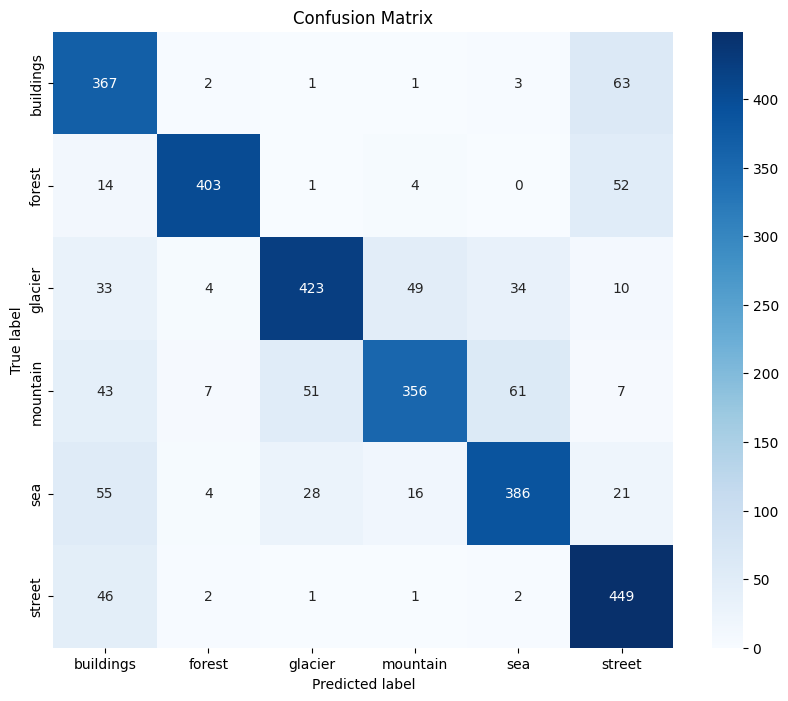

In [313]:
simplecnn_model.show_confusion_matrix(class_names)

SimpleCNN: має найменшу точність. найбільше ця модель плутає будинки і вулиці, а також гори і льодовики. 

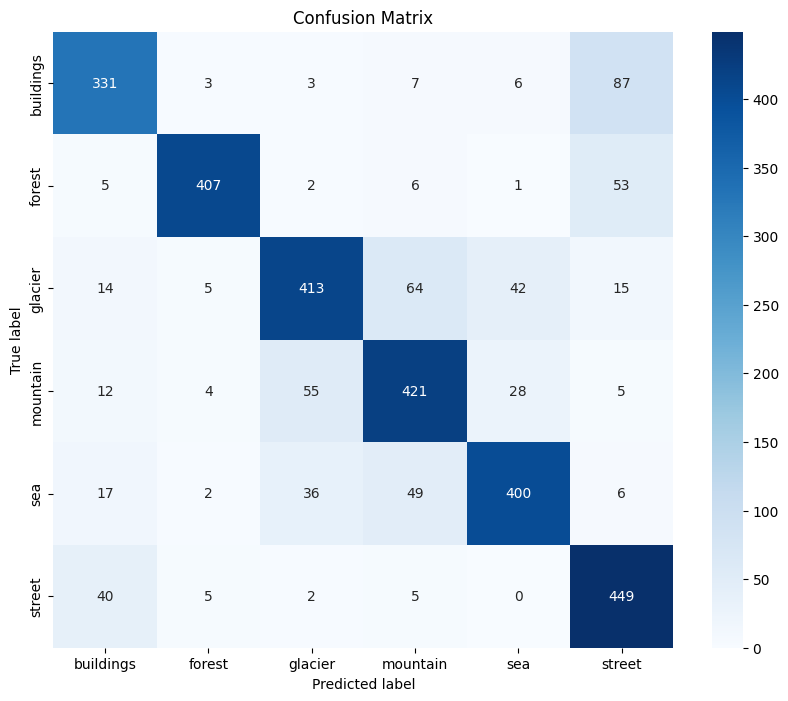

In [287]:
inception_model.show_confusion_matrix(class_names)

InceptionCNN: загалом показує кращі результати, ніж SimpleCNN. Найбільше помиляється при знаходженні вулиць і будинків.


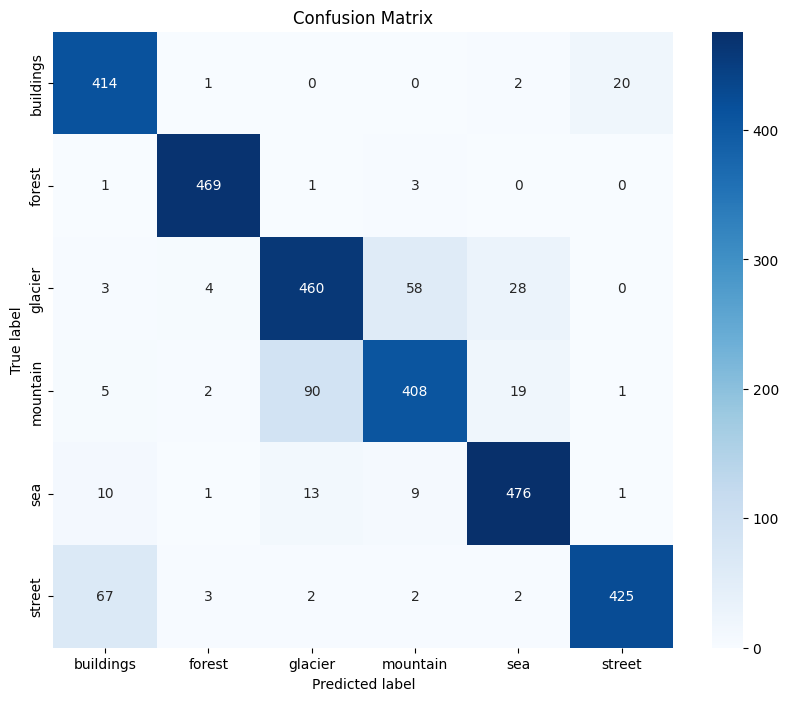

In [288]:
resnet50_model.show_confusion_matrix(class_names)

ResNet50: загалом помиляється менше ніж попередні моделі. Найбільше плутає гори і льодовики, а також будинки і вулиці.

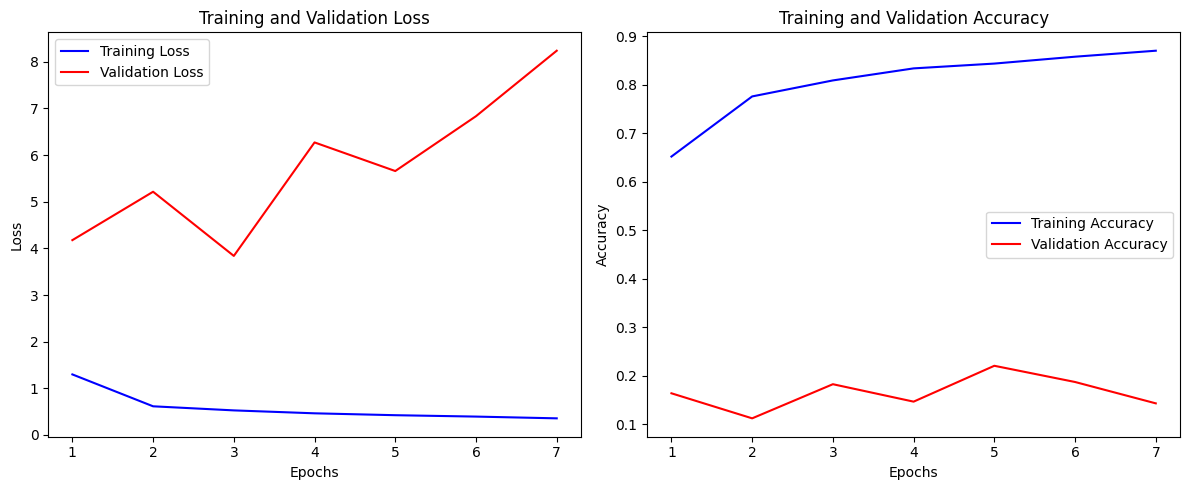

In [309]:
simplecnn_model.plot_training_metrics()

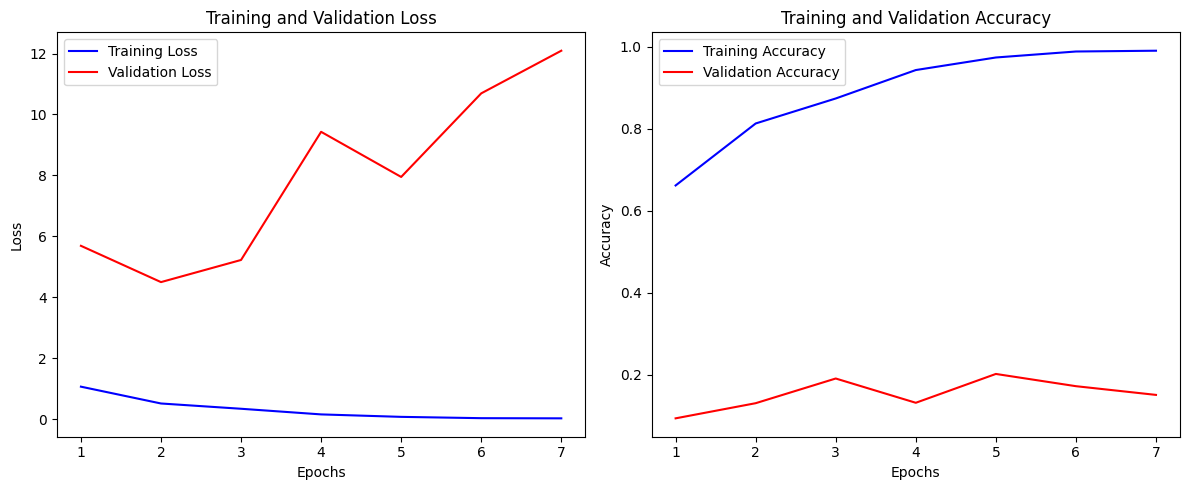

In [290]:
inception_model.plot_training_metrics()

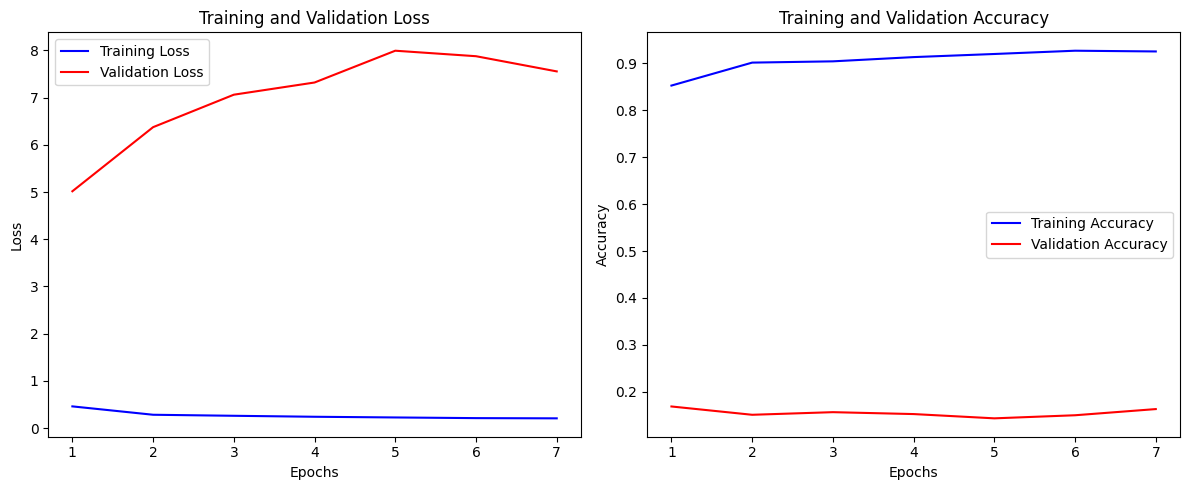

In [291]:
resnet50_model.plot_training_metrics()

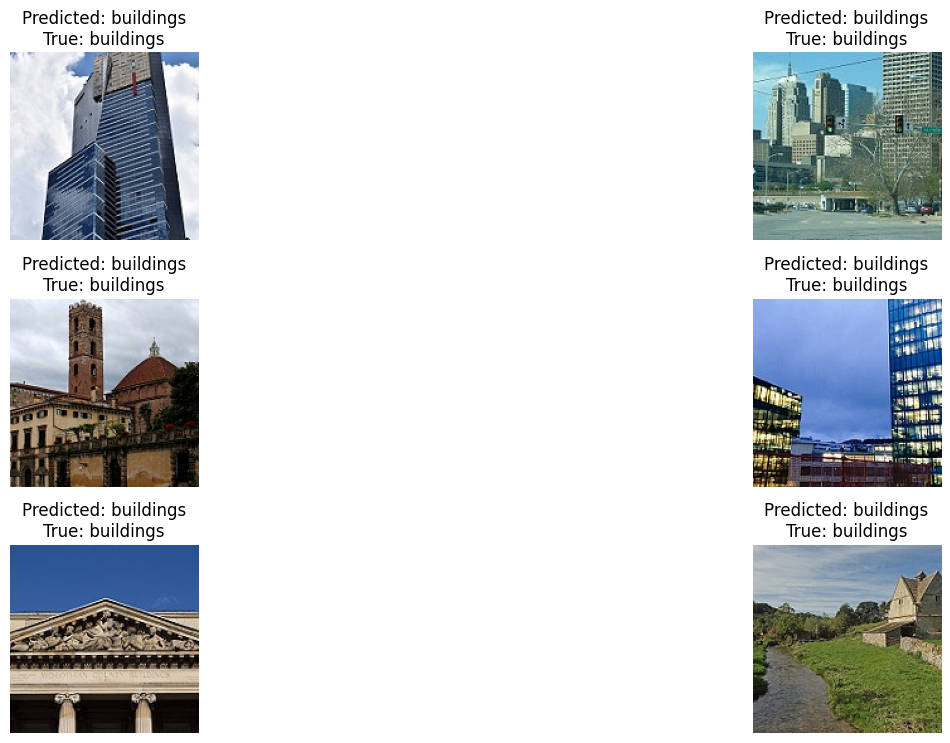

In [314]:
simplecnn_model.visualize_predictions(test_loader, train_dataset.classes, 6)

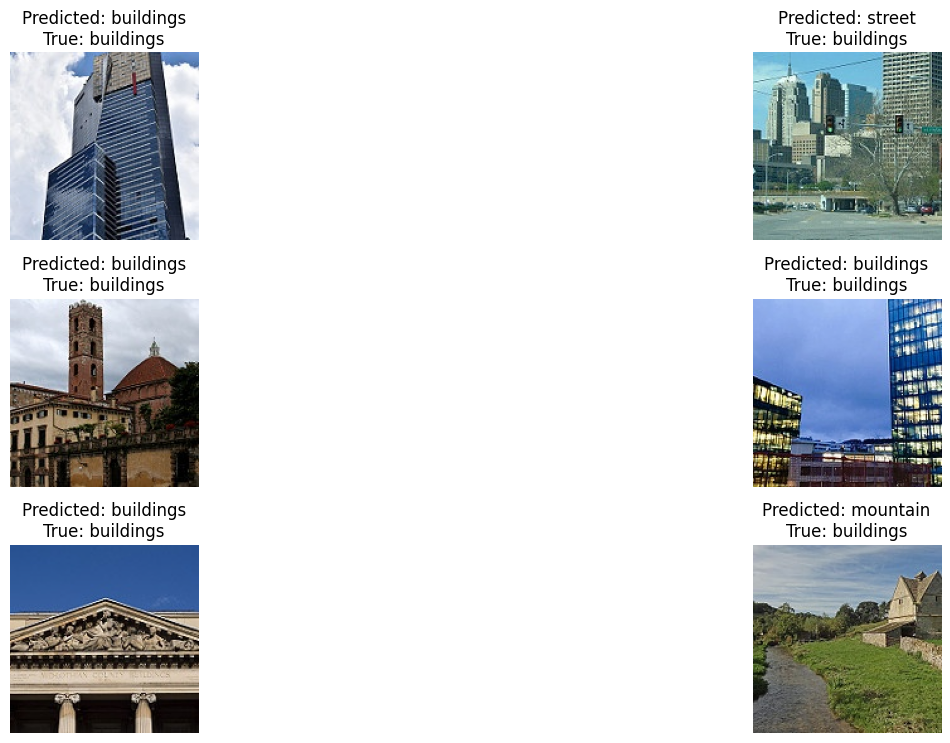

In [293]:
inception_model.visualize_predictions(test_loader, train_dataset.classes, 6)

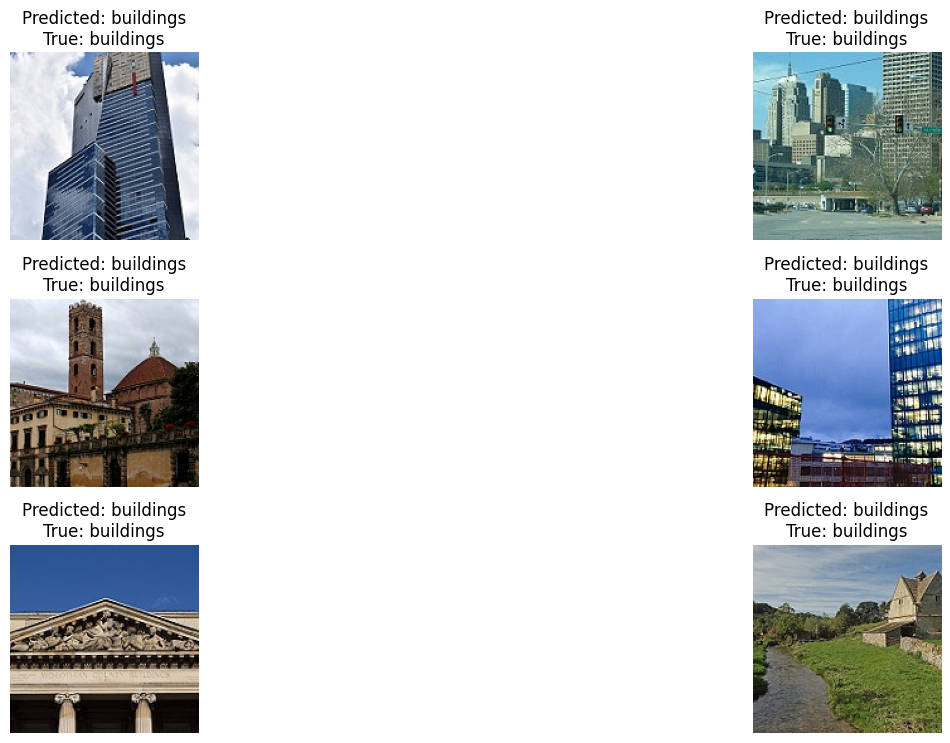

In [294]:
resnet50_model.visualize_predictions(test_loader, train_dataset.classes, 6)

Висновки: в ході виконання цього завдання було розглянуто 3 архітектури нейромережі для класифікації зображень: SimpleCNN, InceptionCNN, ResNet50.
- SimpleCNN взята з практичного заняття як початкова із мінімальними змінами(був дода шар Dropout для уникнення перенавчання). Показує непогані результати - F1 score 0,73-0,79. Ця нейромера здатна розпізнавати якісь прості форми, проте їй не вистачає глибини, щоб відрізняти більш деталі.
- InceptionCNN - структура модуля взята з конспекту з розділу про Inception-v1. Основна ідея Inception-v1 полягає в тому, щоб використовувати низку згорткових шарів різних розмірів ядер паралельно, а потім об'єднувати їх результати за допомогою операції конкатенації. Це дозволяє мережі вибирати оптимальні комбінації фільтрів для виявлення різних ознак на різних рівнях. Результати ця модель показує трохи кращі - F1 score десь 0,75-0,83. Проте як і в першому випадку, цієї нейромережі не вистачає глибини.
- ResNet50 - готова нейромережа, донавчена на наших тренувальних данних, показала найкращий результат - F1 Score 0,78-0,89. Можливо цей результам можна ще покращити, якщо більше погратися з гіперпараметрами.